# Sugar Sugar study analysis

Step-by-step walkthrough of the five library stages.
Uses the same modules as `uv run sugar-data-processing analyze`.

| Stage | Module | Purpose |
| --- | --- | --- |
| 1. Gathering | `gathering` | Load the CSV export and build one MAE score per person |
| 2. Verification | `verification` | Schema checks + demographic / metric quality flags |
| 3. Statistics | `statistics` | Test whether accuracy differs by diabetes, CGM use, experience, and own vs generic data |
| 4. Comparison | `comparison` | Place human MAE against published GlucoBench / literature bands |
| 5. Output | `output` | Write a markdown report with **embedded figure images** |

**Outcome metric:** person-level **MAE** (mean absolute error, mg/dL) for next-hour glucose predictions. Lower is better.

**Setup:** select the `sugar-data-processing (.venv)` kernel, then run the next cell first.

In [1]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path


def _looks_like_repo(path: Path) -> bool:
    return (path / "pyproject.toml").exists() and (
        path / "src" / "sugar_data_processing"
    ).is_dir()


def _notebook_path() -> Path | None:
    for key in ("__vsc_ipynb_file__", "__notebook_path__"):
        raw = globals().get(key)
        if raw:
            path = Path(str(raw)).expanduser().resolve()
            if path.suffix == ".ipynb":
                return path
    try:
        from IPython import get_ipython

        ip = get_ipython()
        if ip is not None:
            for key in ("__vsc_ipynb_file__", "__session__"):
                raw = ip.user_ns.get(key)
                if raw and str(raw).endswith(".ipynb"):
                    return Path(str(raw)).expanduser().resolve()
    except Exception:
        pass
    return None


def _seed_dirs() -> list[Path]:
    import os

    seeds: list[Path] = []
    nb_path = _notebook_path()
    if nb_path is not None:
        seeds.append(nb_path.parent)
    for env_key in (
        "SUGAR_DATA_PROCESSING_ROOT",
        "CURSOR_WORKSPACE",
        "VSCODE_CWD",
        "PWD",
    ):
        raw = os.environ.get(env_key)
        if raw:
            seeds.append(Path(raw).expanduser().resolve())
    seeds.append(Path.cwd().resolve())
    return seeds


def _ensure_package_importable() -> Path | None:
    seen: set[Path] = set()
    for seed in _seed_dirs():
        for candidate in [seed, *seed.parents]:
            if candidate in seen:
                continue
            seen.add(candidate)
            if not _looks_like_repo(candidate):
                continue
            src = candidate / "src"
            if str(src) not in sys.path:
                sys.path.insert(0, str(src))
            return candidate
    if importlib.util.find_spec("sugar_data_processing") is not None:
        return None
    raise RuntimeError(
        "Could not import sugar_data_processing. "
        "Select the project kernel after: uv sync --group dev"
    )


_repo_from_bootstrap = _ensure_package_importable()

# Drop cached package modules so a long-lived kernel picks up src/ edits
for _name in list(sys.modules):
    if _name == "sugar_data_processing" or _name.startswith("sugar_data_processing."):
        del sys.modules[_name]

import polars as pl

from sugar_data_processing import run_analysis
from sugar_data_processing.comparison import benchmark_context
from sugar_data_processing.config import DEFAULT_FIXTURE_CSV, DEFAULT_OUTPUT_DIR, REPO_ROOT
from sugar_data_processing.fixtures.synthetic import write_synthetic_csv
from sugar_data_processing.gathering import (
    build_participant_table,
    load_prediction_statistics,
)
from sugar_data_processing.output import write_report
from sugar_data_processing.statistics.catalog import HYPOTHESES, hypothesis_blurb
from sugar_data_processing.statistics.hypotheses import run_all_hypotheses
from sugar_data_processing.verification import verify_dataset

CSV_PATH = DEFAULT_FIXTURE_CSV
OUTPUT_DIR = DEFAULT_OUTPUT_DIR / "notebook"

if not CSV_PATH.exists():
    write_synthetic_csv(CSV_PATH)

print("repo:", REPO_ROOT)
print("csv:", CSV_PATH)
print("output:", OUTPUT_DIR)
print("hypotheses:", list(HYPOTHESES))
print("imports: ok")


repo: C:\Users\liv\sources\sugar-sugar\sugar-data-processing
csv: C:\Users\liv\sources\sugar-sugar\sugar-data-processing\data\fixtures\synthetic_prediction_statistics.csv
output: C:\Users\liv\sources\sugar-sugar\sugar-data-processing\output\notebook
hypotheses: ['h1', 'h2', 'h3', 'h4', 'h5', 'h6']
imports: ok


## What each hypothesis asks

Study-design codes (H1–H6) are shorthand. Plain-language meanings:

In [2]:
rows = []
for key, info in HYPOTHESES.items():
    rows.append(
        {
            "code": info["code"],
            "title": info["title"],
            "question": info["question"],
            "section": info["section"],
        }
    )
pl.DataFrame(rows)

code,title,question,section
str,str,str,str
"""H1""","""Diabetes status and prediction…","""Do people with diabetes (PwD) …","""§7.3 primary"""
"""H2""","""CGM use and prediction accurac…","""Do continuous glucose monitor …","""§7.3 primary"""
"""H3""","""Diabetes duration and predicti…","""Among people with diabetes, is…","""§7.4 secondary"""
"""H4""","""CGM experience and prediction …","""Among CGM users, is longer CGM…","""§7.4 secondary"""
"""H5""","""Own data vs generic example da…","""Within the same person, is pre…","""§7.4 secondary"""
"""H6""","""Humans vs computational baseli…","""How does human next-hour MAE c…","""§7.4 deferred"""


## 1. Data gathering

Load sugar-sugar `prediction_statistics.csv`, drop identifiers that should not
appear in reports, explode per-round metrics, and build **one row per participant**
with person-level MAE for generic and own data.

In [3]:
runs = load_prediction_statistics(CSV_PATH)
participants = build_participant_table(runs)

print(f"runs={runs.height}, participants={participants.height}")
print(
    "eligible for primary analyses (≥6 generic rounds)=",
    participants.filter(pl.col("eligible_primary")).height,
)
print(
    "eligible for own-vs-generic paired test (≥6 generic and ≥6 own)=",
    participants.filter(pl.col("eligible_h5")).height,
)
participants.select(
    "study_id",
    "diabetic",
    "uses_cgm",
    "mae_primary",
    "n_rounds_generic",
    "n_rounds_own",
    "eligible_primary",
    "eligible_h5",
).head(8)

runs=210, participants=120
eligible for primary analyses (≥6 generic rounds)= 120
eligible for own-vs-generic paired test (≥6 generic and ≥6 own)= 90


study_id,diabetic,uses_cgm,mae_primary,n_rounds_generic,n_rounds_own,eligible_primary,eligible_h5
str,bool,bool,f64,i64,i64,bool,bool
"""9f92aabb-eaab-594d-b282-015fde…",false,true,18.276015,8,0,true,false
"""7e9d9706-cebf-5d92-9471-841c2c…",false,true,11.044384,8,8,true,true
"""05af1ed0-c319-5eca-8766-d0dc15…",false,true,15.676553,8,0,true,false
"""60c1dea1-c937-5df4-855f-e1744f…",true,true,11.860628,8,8,true,true
"""74a0db49-97c6-54a7-8f8f-a3b96a…",true,true,8.450903,8,8,true,true
"""eb56b4d5-0a26-5b26-b9f6-d47590…",false,true,12.88672,8,8,true,true
"""3f8e90e5-e3f5-5da1-9d90-9d97cc…",false,true,22.359498,8,8,true,true
"""a79d5236-82eb-5386-8415-a93fb7…",true,false,21.125869,8,8,true,true


## 2. Data verification

Check that required columns / formats look valid, then flag implausible
demographics and metric outliers. Schema failures are serious; quality flags
are reported for review.

In [4]:
verification = verify_dataset(runs, participants)
print("schema_ok:", verification.schema_ok)
print("passed:", verification.passed)
print(
    f"issues: {len(verification.all_issues)} "
    f"(schema={len(verification.schema_issues)}, "
    f"quality={len(verification.quality_flags)}; "
    f"high={verification.n_high}, medium={verification.n_medium})"
)
for issue in verification.all_issues[:15]:
    print(f"  [{issue.severity}] {issue.category}: {issue.detail} ({issue.study_id})")

schema_ok: True
passed: True
issues: 5 (schema=0, quality=5; high=3, medium=2)
  [high] diabetes_duration_gt_age: diabetes_duration=21.91488714066286 > age=18.0 (74a0db49-97c6-54a7-8f8f-a3b96a91ad30)
  [high] cgm_duration_gt_age: cgm_duration_years=58.0 > age=53.0 (27ba2f05-f7cb-5c3f-b6f2-075df79abf2c)
  [high] implausible_cgm_duration: cgm_duration_years=58.0 (plausible ≤ 30.0) (27ba2f05-f7cb-5c3f-b6f2-075df79abf2c)
  [medium] mae_iqr_outlier: mae_primary=90.74 outside IQR fence [-0.53, 30.91] (daea1a90-f40c-5ac0-9663-6e8cabd3b0ba)
  [medium] mae_iqr_outlier: mae_primary=33.51 outside IQR fence [-0.53, 30.91] (f02b2d28-7209-5349-b271-b5a9a4088c27)


## 3. Statistical tests

Run the study-design battery on person-level MAE:

- **H1 — Diabetes status:** are PwD more accurate than non-PwD?
- **H2 — CGM use:** are CGM users more accurate than non-CGM users?
- **H3 — Diabetes duration:** among PwD, does longer duration go with lower MAE?
- **H4 — CGM experience:** among CGM users, does longer experience go with lower MAE?
- **H5 — Own vs generic:** within person, is own-data MAE lower than generic-data MAE?
- **H6 — Humans vs models:** deferred until baselines exist in sugar-sugar.

In [5]:
suite = run_all_hypotheses(participants)
payload = suite.to_dict()

for key in ("h1", "h2", "h3", "h4", "h5", "h6"):
    print(hypothesis_blurb(key))
    result = payload.get(key)
    if key == "h6":
        print("  status:", result.get("status"), "-", result.get("note"))
        print()
        continue
    if result is None:
        print("  result: skipped / insufficient sample\n")
        continue
    p_value = result.get("p_value")
    p_text = f"{p_value:.4g}" if isinstance(p_value, (int, float)) else str(p_value)
    print(
        f"  test={result.get('test_used')}  p={p_text}  "
        f"significant={result.get('significant')}"
    )
    print(f"  interpretation: {result.get('interpretation')}\n")

print("pipeline notes:", suite.notes)

**H1 — Diabetes status and prediction accuracy** (§7.3 primary)

- **Question:** Do people with diabetes (PwD) predict next-hour glucose more accurately than people without diabetes?
- **Compared / predictor:** PwD vs non-PwD (`diabetic`)
- **Outcome:** Person-level MAE in mg/dL (lower is better)
- **Test plan:** Shapiro–Wilk normality check, then independent t-test if normal, otherwise Mann–Whitney U. α = 0.05.
  test=mann_whitney_u  p=2.375e-07  significant=True
  interpretation: Significant difference (p=2.375e-07, mann_whitney_u). Mean MAE PwD=13.84, non-PwD=18.08 mg/dL → PwD lower MAE (better).

**H2 — CGM use and prediction accuracy** (§7.3 primary)

- **Question:** Do continuous glucose monitor (CGM) users predict next-hour glucose more accurately than people who do not use CGM?
- **Compared / predictor:** CGM users vs non-CGM (`uses_cgm`)
- **Outcome:** Person-level MAE in mg/dL (lower is better)
- **Test plan:** Same path as H1: Shapiro–Wilk → independent t-test or Mann–Whitne

## 4. Data comparison

Place the human cohort's person-level MAE against published 60-minute
GlucoBench / literature bands (simple/ARIMA, deep learning, personalized).

In [6]:
eligible = participants.filter(pl.col("eligible_primary"))
bench_frame = eligible if eligible.height > 0 else participants
benchmarks = benchmark_context(bench_frame, mae_col="mae_primary")
print(benchmarks.narrative)
benchmarks.to_dict()

Human mean MAE is 16.0 mg/dL (median 15.5, SD 8.9, n=120), which sits inside the published simple-baseline band. Reference 60-min bands — simple/ARIMA 12–20, deep learning 11–17, personalized 15–17 mg/dL (study design §7.5).


{'n': 120,
 'human_mean_mae': 15.9596553739315,
 'human_median_mae': 15.498091688662907,
 'human_sd_mae': 8.938806173285826,
 'pct_below_simple_baseline_low': 29.166666666666668,
 'pct_inside_simple_baseline_band': 48.333333333333336,
 'pct_inside_deep_learning_band': 39.166666666666664,
 'pct_inside_personalized_band': 16.666666666666664,
 'simple_baseline_mae_range': (12.0, 20.0),
 'deep_learning_mae_range': (11.0, 17.0),
 'personalized_mae_range': (15.0, 17.0),
 'narrative': 'Human mean MAE is 16.0 mg/dL (median 15.5, SD 8.9, n=120), which sits inside the published simple-baseline band. Reference 60-min bands — simple/ARIMA 12–20, deep learning 11–17, personalized 15–17 mg/dL (study design §7.5).'}

## 5. Output

Write figures + a markdown report. Images are embedded inside the `.md` as
base64 PNGs (and also copied to `reports/figures/`).

report: C:\Users\liv\sources\sugar-sugar\sugar-data-processing\output\notebook\reports\study_analysis_report.md
figures: C:\Users\liv\sources\sugar-sugar\sugar-data-processing\output\notebook\reports\figures

=== Overall distribution of per-person MAE ===


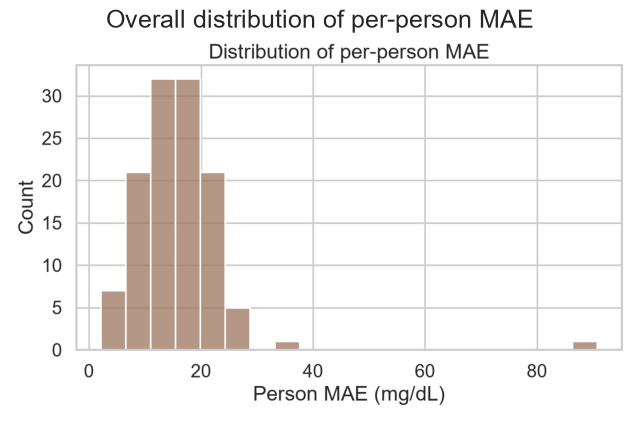


=== H1 - Diabetes status: person MAE for PwD vs non-PwD ===


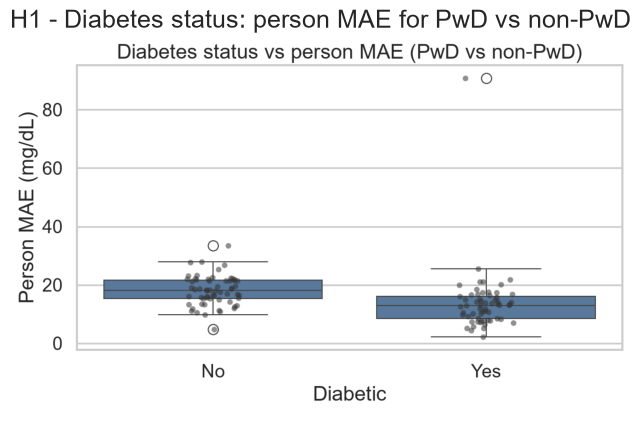


=== H2 - CGM use: person MAE for CGM users vs non-users ===


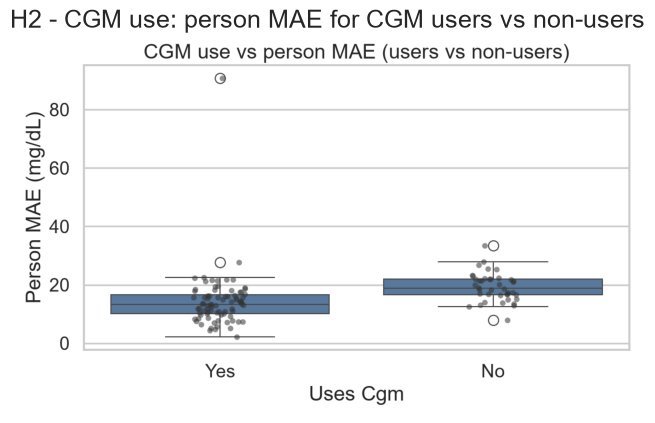


=== H3 - Diabetes duration vs MAE among PwD ===


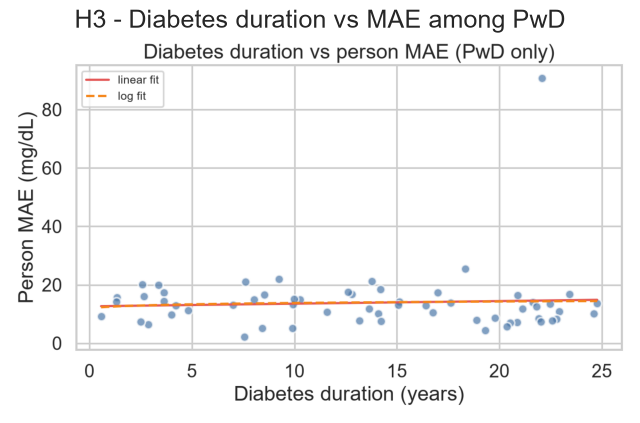


=== H4 - CGM experience vs MAE among CGM users ===


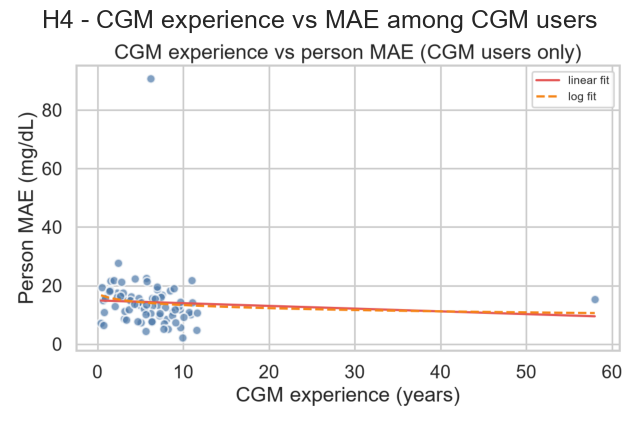


=== Exploratory MAE by duration / experience bins ===


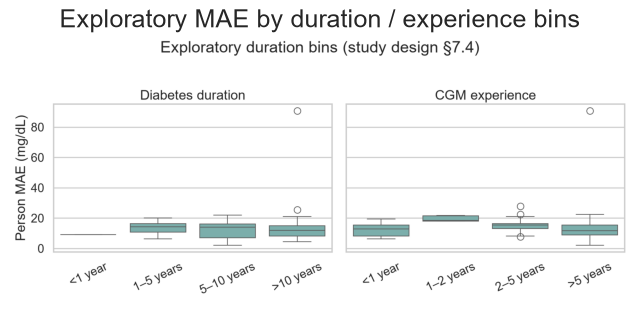


=== H5 - Own-data MAE vs generic-data MAE (paired) ===


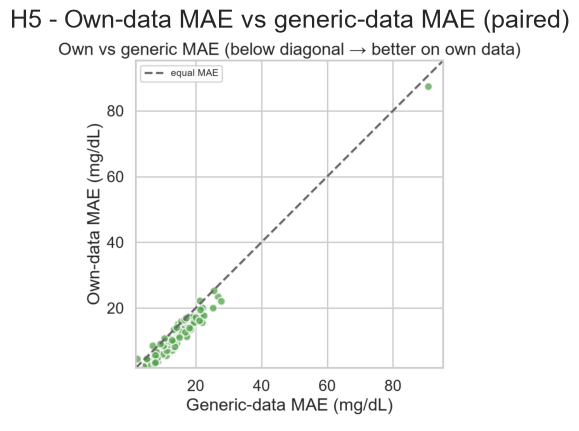


=== Human MAE vs published literature bands ===


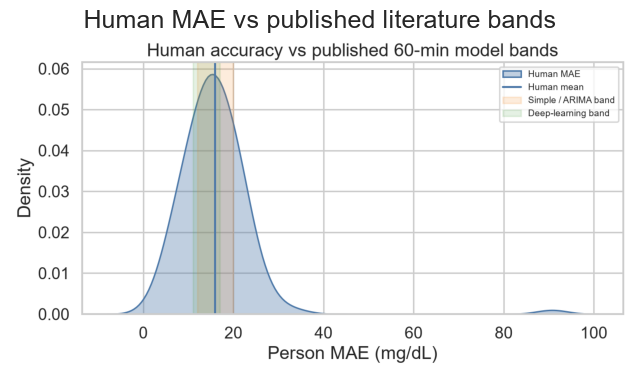

In [7]:
# SHOW FIGURES - matplotlib only (does not use IPython Markdown)
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

report_path = write_report(
    runs=runs,
    participants=participants,
    suite=suite,
    benchmarks=benchmarks,
    verification=verification,
    output_dir=OUTPUT_DIR,
    source_csv=CSV_PATH,
)
figures_dir = OUTPUT_DIR / 'reports' / 'figures'
print('report:', report_path)
print('figures:', figures_dir)

figure_captions = [
    ('mae_distribution.png', 'Overall distribution of per-person MAE'),
    ('h1_mae_by_diabetes.png', 'H1 - Diabetes status: person MAE for PwD vs non-PwD'),
    ('h2_mae_by_cgm.png', 'H2 - CGM use: person MAE for CGM users vs non-users'),
    ('h3_diabetes_duration_scatter.png', 'H3 - Diabetes duration vs MAE among PwD'),
    ('h4_cgm_duration_scatter.png', 'H4 - CGM experience vs MAE among CGM users'),
    ('h3_h4_duration_bins.png', 'Exploratory MAE by duration / experience bins'),
    ('h5_own_vs_generic.png', 'H5 - Own-data MAE vs generic-data MAE (paired)'),
    ('benchmark_human_vs_literature.png', 'Human MAE vs published literature bands'),
]
for name, caption in figure_captions:
    path = figures_dir / name
    print(f'\n=== {caption} ===')
    if not path.exists():
        print('missing:', path)
        continue
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(mpimg.imread(path))
    ax.set_axis_off()
    ax.set_title(caption)
    plt.show()
    plt.close(fig)


## One-shot alternative

Same stages in a single `run_analysis` call:

In [8]:
result = run_analysis(CSV_PATH, OUTPUT_DIR / "one_shot")
print(result.report_path)
print("verification.passed:", result.verification.passed)
print("mean MAE (mg/dL):", result.benchmarks.human_mean_mae)
print(
    "report embeds images:",
    "data:image/png;base64," in result.report_path.read_text(encoding="utf-8"),
)

C:\Users\liv\sources\sugar-sugar\sugar-data-processing\output\notebook\one_shot\reports\study_analysis_report.md
verification.passed: True
mean MAE (mg/dL): 15.9596553739315
report embeds images: True
